### Normalization 
Normalization is a data preprocessing technique that scales numerical features to a common range, typically 0 to 1, so that features with larger values don't disproportionately influence the model.

**Type of Normalization**
- 1. MinMax Scaling
- 2. Mean Normalization
- 3. Max absolute scaling
- 4. Robust Scaling
many more

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Min-Max Scaling

**Formula:**

$$
X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

It scales numerical values to a **range of 0 to 1**.

In [37]:
x = np.array([20, 30, 40, 50, 60])

x_scaled = (x - x.min()) / (x.max() - x.min())

x_scaled

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [38]:
df = pd.read_csv("../../datasets/wine_data.csv", usecols=[0,1,2])
df.columns =["Class label", "Alcohol","Malic acid"]

In [39]:
df.head()

,Class label,Alcohol,Malic acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76


<Axes: xlabel='Alcohol', ylabel='Density'>

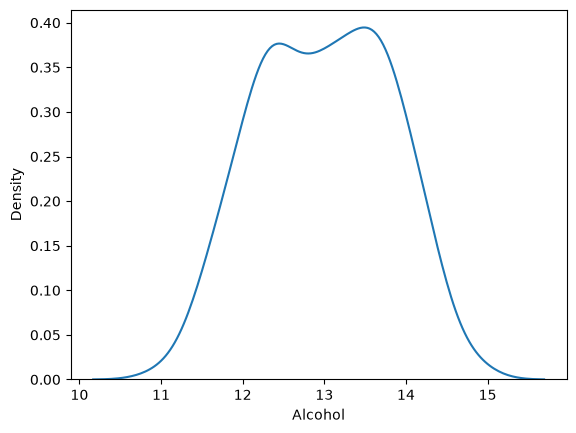

In [40]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Malic acid', ylabel='Density'>

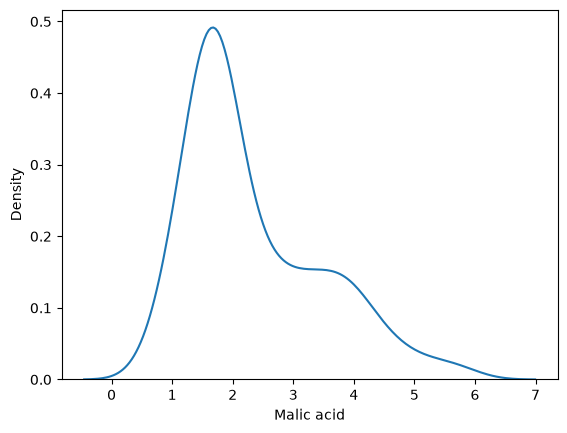

In [41]:
sns.kdeplot(df["Malic acid"])

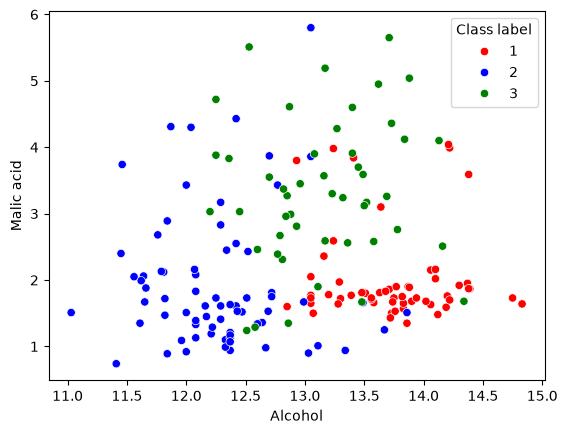

In [42]:
color_dict = {
    1: "red",
    2: "blue",
    3: "green"
}

sns.scatterplot(
    x="Alcohol",
    y="Malic acid",
    hue="Class label",
    palette=color_dict,
    data=df
)

plt.show()

In [43]:
X =df.drop("Class label", axis="columns")
y = df["Class label"]

In [44]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,
                                                       test_size=0.3,
                                                       random_state=0)

In [45]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((123, 2), (54, 2), (123,), (54,))

In [46]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [48]:
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [58]:
np.round(X_train.describe(),2)

,Alcohol,Malic acid
count,123.00,123.00
mean,12.98,2.33
std,0.78,1.17
min,11.03,0.89
25%,12.37,1.56
50%,13.05,1.83
75%,13.62,3.08
max,14.75,5.80


In [59]:
np.round(X_train_scaled.describe(),2)

,Alcohol,Malic acid
count,123.00,123.00
mean,0.52,0.29
std,0.21,0.24
min,0.00,0.00
25%,0.36,0.14
50%,0.54,0.19
75%,0.70,0.45
max,1.00,1.00


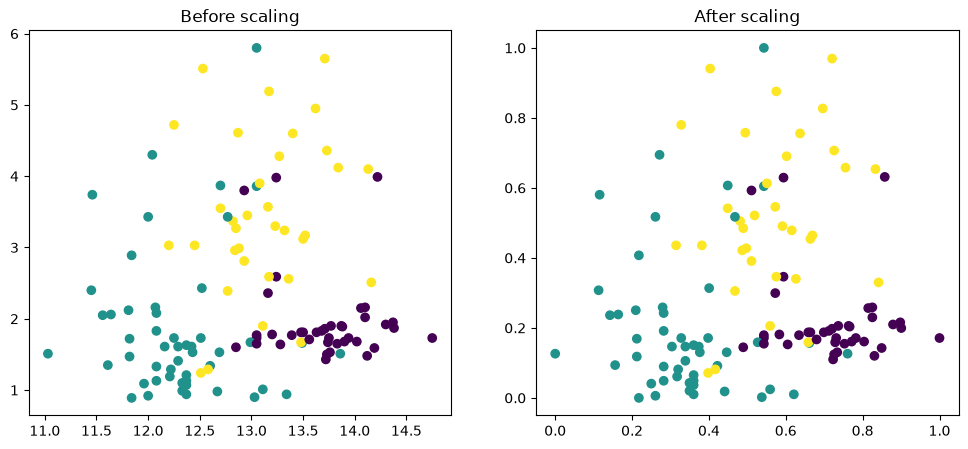

In [64]:
fig , (ax1,ax2) =plt.subplots(ncols=2, figsize =(12,5))

ax1.scatter(X_train["Alcohol"], X_train["Malic acid"], c=y_train)
ax1.set_title("Before scaling")
ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic acid"], c=y_train)
ax2.set_title("After scaling");

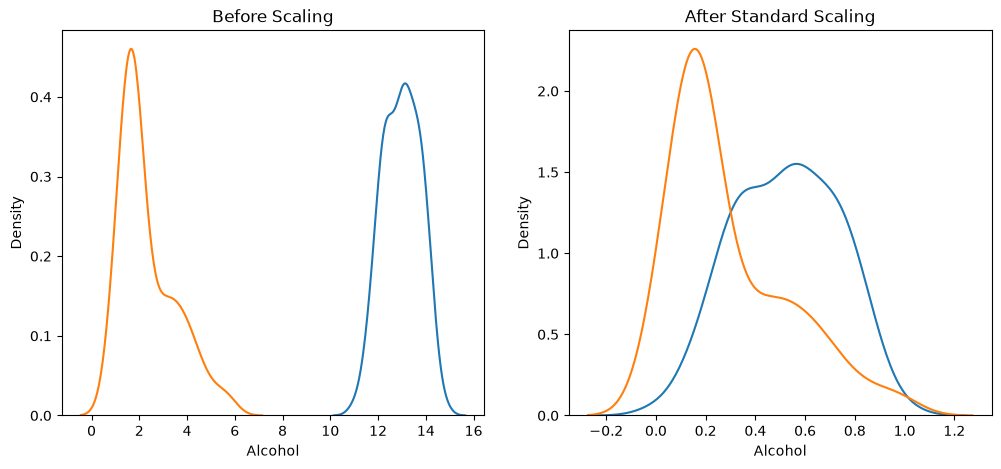

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

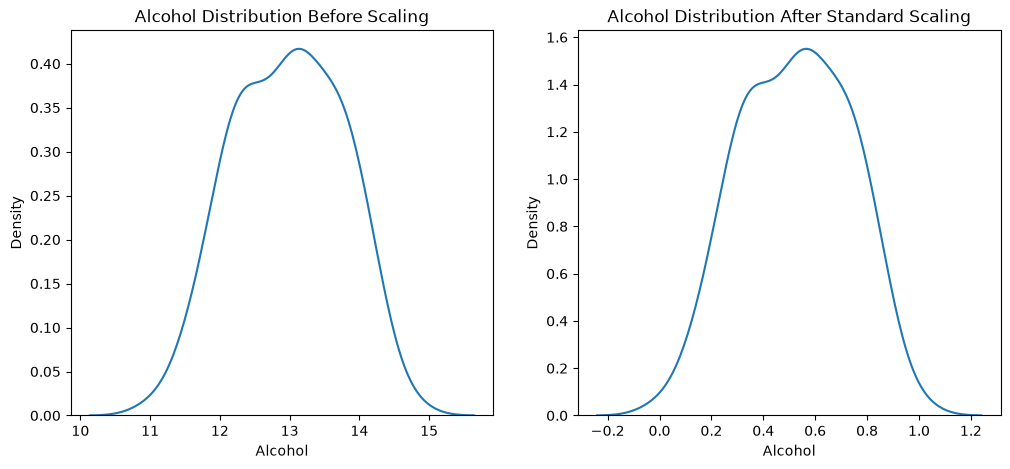

In [66]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

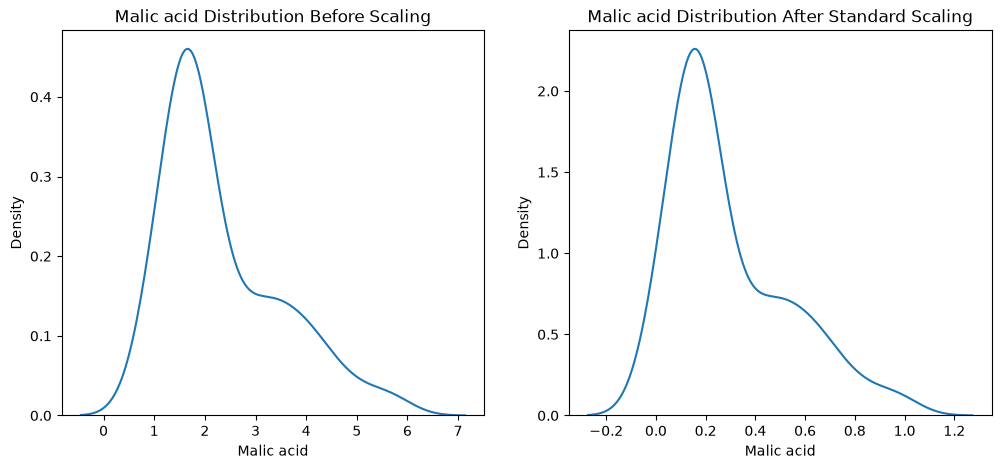

In [67]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

### Mean Normalization

**Formula:**

$$
X_{\text{scaled}} = \frac{X - \mu}{X_{\max} - X_{\min}}
$$

Where:

- $\mu$ = mean of the feature
- $X_{\max}$ = maximum value
- $X_{\min}$ = minimum value

range = [-1, 1]

### Max Absolute Scaling

**Formula:**

$$
X_{\text{scaled}} = \frac{X}{\max(|X|)}
$$

Where:

- $\max(|X|)$ = maximum absolute value in the feature

**Result:** Values are scaled to the range **-1 to 1**.

useful for sparsh data

### Robust Scaling

**Formula:**

$$
X_{\text{scaled}} = \frac{X - \text{Median}}{\text{IQR}}
$$

Where:

- **Median** = middle value of the feature
- **IQR** = Interquartile Range
- **IQR = Q3 - Q1**

**Why use it?**

Robust Scaling is useful when the data contains **outliers**, because the median and IQR are less affected by extreme values.